In [ ]:
! pip install -q kaggle

In [ ]:
# prompt: fix above problem

from google.colab import files

files.upload()

# Create a directory for Kaggle configuration files if it doesn't exist
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/
# Make the kaggle.json file executable (required by the Kaggle API)
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
#! mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c seed-classification

 90% 127M/142M [00:00<00:00, 1.33GB/s]
100% 142M/142M [00:00<00:00, 1.33GB/s]


In [ ]:
!unzip seed-classification.zip

Archive:  seed-classification.zip
  inflating: Sample_submission.csv   
  inflating: files/test/102871.png   
  inflating: files/test/106683.png   
  inflating: files/test/110070.png   
  inflating: files/test/110180.png   
  inflating: files/test/114155.png   
  inflating: files/test/116806.png   
  inflating: files/test/118560.png   
  inflating: files/test/1207.png     
  inflating: files/test/126174.png   
  inflating: files/test/128328.png   
  inflating: files/test/128775.png   
  inflating: files/test/129067.png   
  inflating: files/test/129927.png   
  inflating: files/test/131447.png   
  inflating: files/test/134742.png   
  inflating: files/test/137114.png   
  inflating: files/test/139159.png   
  inflating: files/test/149237.png   
  inflating: files/test/152378.png   
  inflating: files/test/154930.png   
  inflating: files/test/157238.png   
  inflating: files/test/158649.png   
  inflating: files/test/161042.png   
  inflating: files/test/164480.png   
  inflating: fil

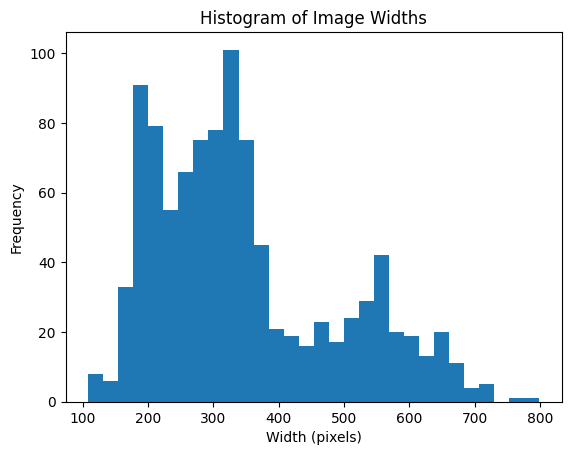

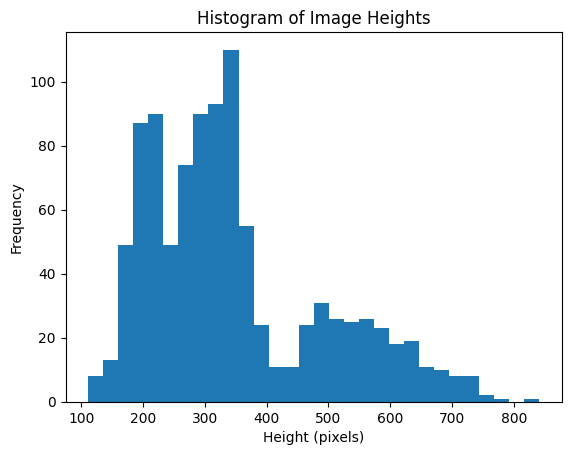

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Replace with your root directory
root_dir = "."

# Lists to store dimensions
widths = []
heights = []

# Walk through all subdirectories and files
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        # Optional: filter image extensions
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")
        ):
            file_path = os.path.join(dirpath, filename)
            try:
                with Image.open(file_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

# Plot width histogram
plt.figure()
plt.hist(widths, bins=30)
plt.title("Histogram of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.show()

# Plot height histogram
plt.figure()
plt.hist(heights, bins=30)
plt.title("Histogram of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# prompt: define train variable = /content/train.csv read

import pandas as pd

train = pd.read_csv("/content/train.csv")

In [ ]:
classes = sorted(train["class"].unique())
class2idx = {classes[i]: i for i in range(len(classes))}
idx2class = {i: classes[i] for i in range(len(classes))}

In [ ]:
import os
from tqdm import tqdm

for idx, row in tqdm(train.iterrows()):
    class_idx = class2idx[row["class"]]
    os.system(f"mkdir -p dataset/{class_idx}")
    os.system(f'cp files/train/{row["file_id"]}.png dataset/{class_idx}/')

498it [00:01, 256.83it/s]


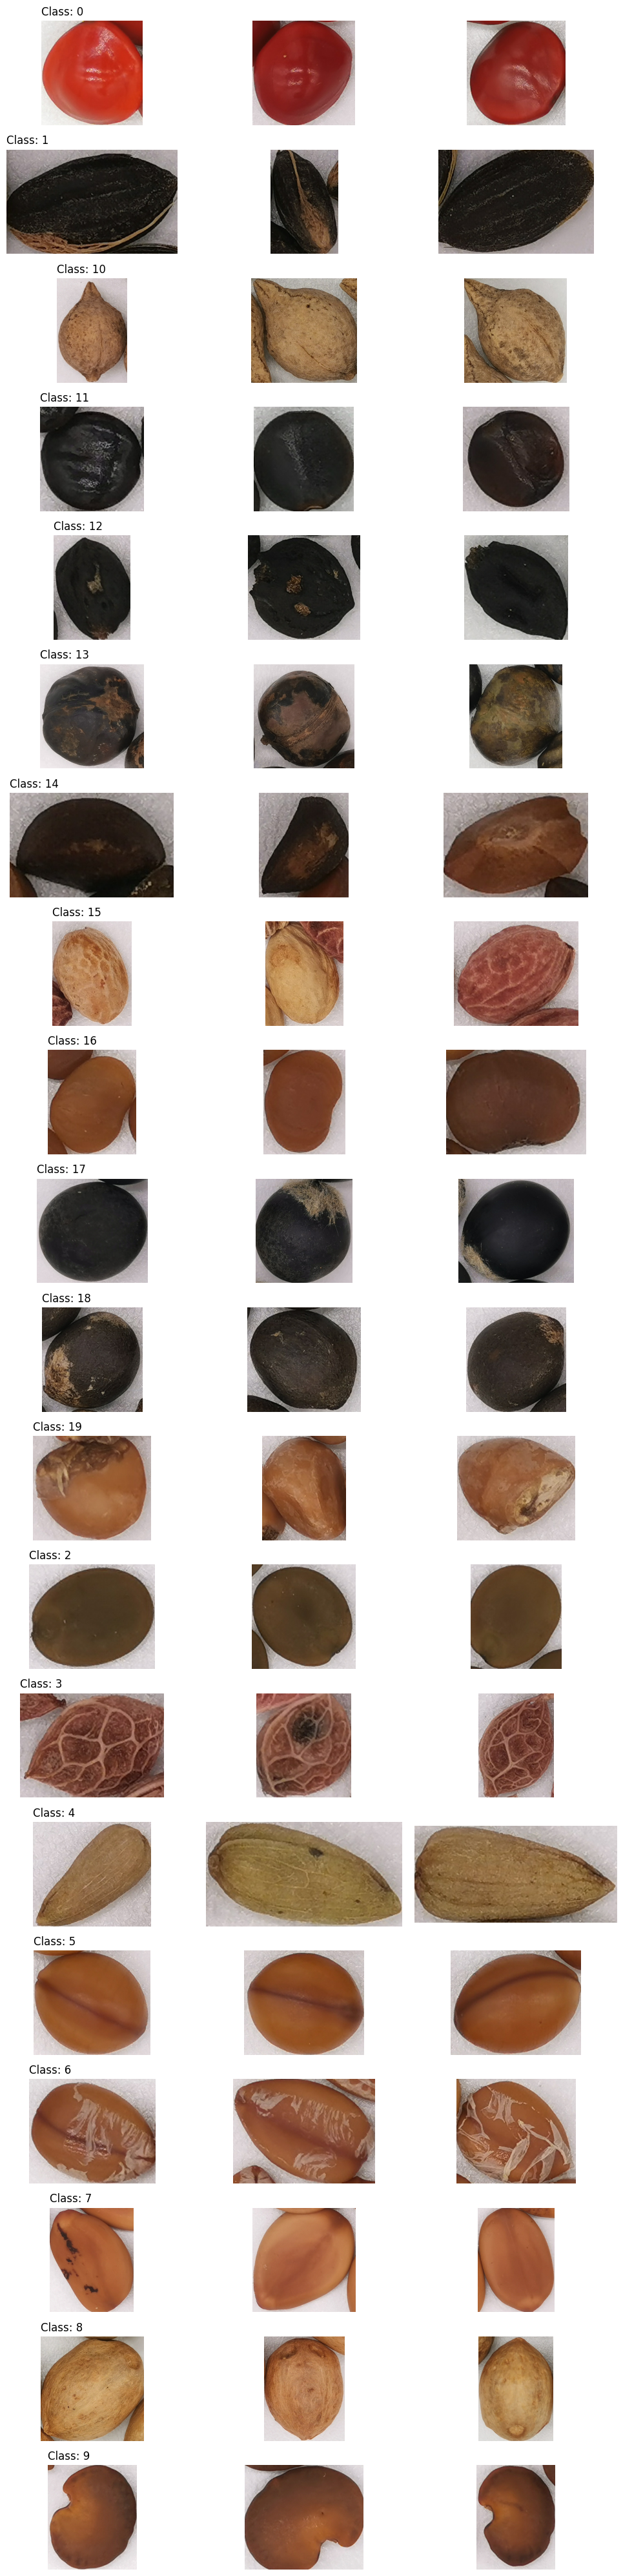

In [ ]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


def visualize_class_samples(
    root_dir: str,
    classes: list[str] = None,
    samples_per_class: int = 4,
    figsize=(12, 8),
):
    """
    Displays a grid of sample images, per class.

    Args:
        root_dir: path to dataset structured as root_dir/<class_name>/*.jpg
        classes: list of class folder names to visualize (defaults to all subfolders)
        samples_per_class: number of images to show per class
        figsize: overall figure size
    """
    root = Path(root_dir)
    all_classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    if classes is None:
        classes = all_classes
    else:
        # filter out non-existing classes
        classes = [c for c in classes if c in all_classes]

    n_classes = len(classes)
    cols = samples_per_class
    rows = n_classes

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes[None, :]  # ensure 2D indexing

    for row, cls in enumerate(classes):
        cls_path = root / cls
        images = list(cls_path.glob("*.*"))
        if len(images) == 0:
            print(f"⚠️ No images found in class: {cls}")
            continue
        selected = random.sample(images, min(samples_per_class, len(images)))
        for col, img_path in enumerate(selected):
            img = Image.open(img_path).convert("RGB")
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(f"Class: {cls}", loc="left")
    plt.tight_layout()
    plt.show()


# Visualize 3 samples per class for all classes
visualize_class_samples(
    "dataset",
    samples_per_class=3,
    figsize=(10, 2 * len(os.listdir("dataset/"))),
)

In [22]:
!torchrun --nproc_per_node=1 train.py \
--data_dir dataset --epochs 30 --patience 3\
--model_dir microsoft/swin-large-patch4-window12-384-in22k --batch_size 32

2025-07-01 16:41:25.073275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751388085.093984   23860 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751388085.100370   23860 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will cre

In [23]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ------------------------ Config ------------------------
MODEL_DIR = "finetune/"
IMAGE_DIR = "files/test/"
CSV_PATH = "test.csv"
OUTPUT_CSV = "submission.csv"
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------- Load Model & Processor --------------------
torch.cuda.empty_cache()

processor = AutoImageProcessor.from_pretrained(MODEL_DIR)
model = AutoModelForImageClassification.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()
model = torch.compile(model)

# -------------------- Load CSV --------------------
test_df = pd.read_csv(CSV_PATH)

# -------------------- Image Loader --------------------
def load_image(image_id):
    for ext in [".jpg", ".png"]:
        path = os.path.join(IMAGE_DIR, image_id + ext)
        if os.path.exists(path):
            return Image.open(path).convert("RGB")
    raise FileNotFoundError(f"Image not found for ID: {image_id}")


# -------------------- Batch Prediction --------------------
predictions = []

for i in tqdm(range(0, len(test_df), BATCH_SIZE), desc="Predicting"):
    batch_ids = test_df["file_id"].iloc[i : i + BATCH_SIZE].tolist()
    batch_images = [load_image(str(image_id)) for image_id in batch_ids]

    inputs = processor(images=batch_images, return_tensors="pt", padding=True).to(
        DEVICE
    )
    with torch.inference_mode():
        logits = model(**inputs).logits
    preds = torch.argmax(logits, dim=-1).tolist()

    predictions.extend(preds)

Predicting:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)
Predicting:  25%|██▌       | 1/4 [01:24<04:14, 84.90s/it]/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)
Predicting: 100%|██████████| 4/4 [03:10<00:00, 47.58s/it]


In [24]:
# -------------------- Save Results --------------------
test_df["class"] = predictions
test_df["class"] = test_df["class"].map(idx2class)
test_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Saved predictions to: {OUTPUT_CSV}")
test_df


✅ Saved predictions to: submission.csv


,file_id,class
0,737808,adenanthera_pavonina
1,5807,trewia_nudiflora
2,72616,cassia_bakeriana
3,26829,turpinia_pomifera
4,432819,cassia_fistula
...,...,...
494,905549,drypetes_roxburghii
495,506738,adenanthera_pavonina
496,441155,cassia_grandis
497,193925,rhus_rhetsoides


In [25]:
!kaggle competitions submit -c seed-classification -f submission.csv -m "Message"

100% 12.0k/12.0k [00:00<00:00, 31.4kB/s]
Successfully submitted to Image Processing: Seed Classification